# Data Analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('viridis', 8)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

SCRIPT_DIR        = pathlib.Path('.')
CSV_PATH          = SCRIPT_DIR / 'issues.csv'
PLOTS_ROOT        = SCRIPT_DIR / 'multi_plots'
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

RESOLVED_STATUSES = {'Resolved', 'Closed'}

print('Setup OK.')

Setup OK.


## Load Data

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f'Raw shape : {df_raw.shape}')
print(f'Projects  : {sorted(df_raw["project"].unique())}')
print('\nNull counts:')
print(df_raw.isnull().sum())


Raw shape : (12169, 13)
Projects  : ['FLINK', 'HDDS', 'IGNITE', 'KAFKA', 'SPARK']

Null counts:
project                 0
_id                     0
key                     0
issuetype_name          0
priority_name           0
status_name             0
age_days                0
watch_count             0
votes_count             0
has_assignee            0
components_count        0
comment_count           0
status_changes_count    0
dtype: int64


## Helper Functions

In [ ]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    CORE = ['issuetype_name', 'priority_name', 'status_name',
            'age_days', 'watch_count', 'votes_count', 'has_assignee']
    return out.dropna(subset=CORE).reset_index(drop=True)


def plot_categorical_distributions(df, title_prefix, plot_dir):
    cat_cols   = ['issuetype_name', 'priority_name', 'status_name']
    cat_titles = ['Issue Type', 'Priority', 'Status']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Categorical Distributions — {title_prefix}', fontsize=14)
    for ax, col, title in zip(axes, cat_cols, cat_titles):
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, ax=ax,
                      palette='viridis', edgecolor='white', linewidth=0.5)
        ax.set_title(title); ax.set_xlabel('Count'); ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(plot_dir / 'categorical_distributions.png', bbox_inches='tight')
    plt.show()


def plot_numeric_distributions(df, title_prefix, plot_dir):
    num_cols   = ['age_days', 'watch_count', 'votes_count', 'status_changes_count', 'components_count', 'comment_count']
    num_titles = ['Age (days)', 'Watch Count', 'Votes Count', 'Status Changes Count', 'Components Count', 'Comment Count']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Numeric Distributions — {title_prefix}', fontsize=14)
    axes = axes.flatten()
    for ax, col, title in zip(axes, num_cols, num_titles):
        data = df[col]
        kw = dict(bins=40, ax=ax, color=PALETTE[2], edgecolor='white', linewidth=0.3)
        sns.histplot(data, **kw)
        ax.set_title(title); ax.set_xlabel(title); ax.set_ylabel('Count')
        ax.axvline(data.median(), color='crimson', linestyle='--', linewidth=1.2,
                   label=f'Median={data.median():.1f}')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(plot_dir / 'numeric_distributions.png', bbox_inches='tight')
    plt.show()


def run_full_analysis(df: pd.DataFrame, label: str, plot_dir: pathlib.Path):
    """
    End-to-end analysis pipeline for a given data slice.
    """
    print('\n' + '=' * 70)
    print(f'  ANALYSIS: {label}  ({len(df):,} issues)')
    print('=' * 70)
    plot_dir.mkdir(parents=True, exist_ok=True)

    df_main = preprocess(df)
    print(f'  Working frame: {df_main.shape[0]:,} rows x {df_main.shape[1]} cols')
    print('\n  Status distribution:')
    print(df_main['status_name'].value_counts().to_string())

    plot_categorical_distributions(df_main, label, plot_dir)
    plot_numeric_distributions(df_main, label, plot_dir)

    print(f'\n  Done — plots saved to: {plot_dir}')
    return df_main


print('Helper functions defined.')

Helper functions defined.


---
# 1 · Full Dataset (All 5 Projects Combined)



  ANALYSIS: All Projects (FLINK + HDDS + IGNITE + KAFKA + SPARK) 2024  (12,169 issues)
  Working frame: 12,169 rows x 13 cols

  Status distribution:
status_name
Resolved           7312
Open               3803
Closed              748
In Progress         177
Patch Available      88
Reopened             41


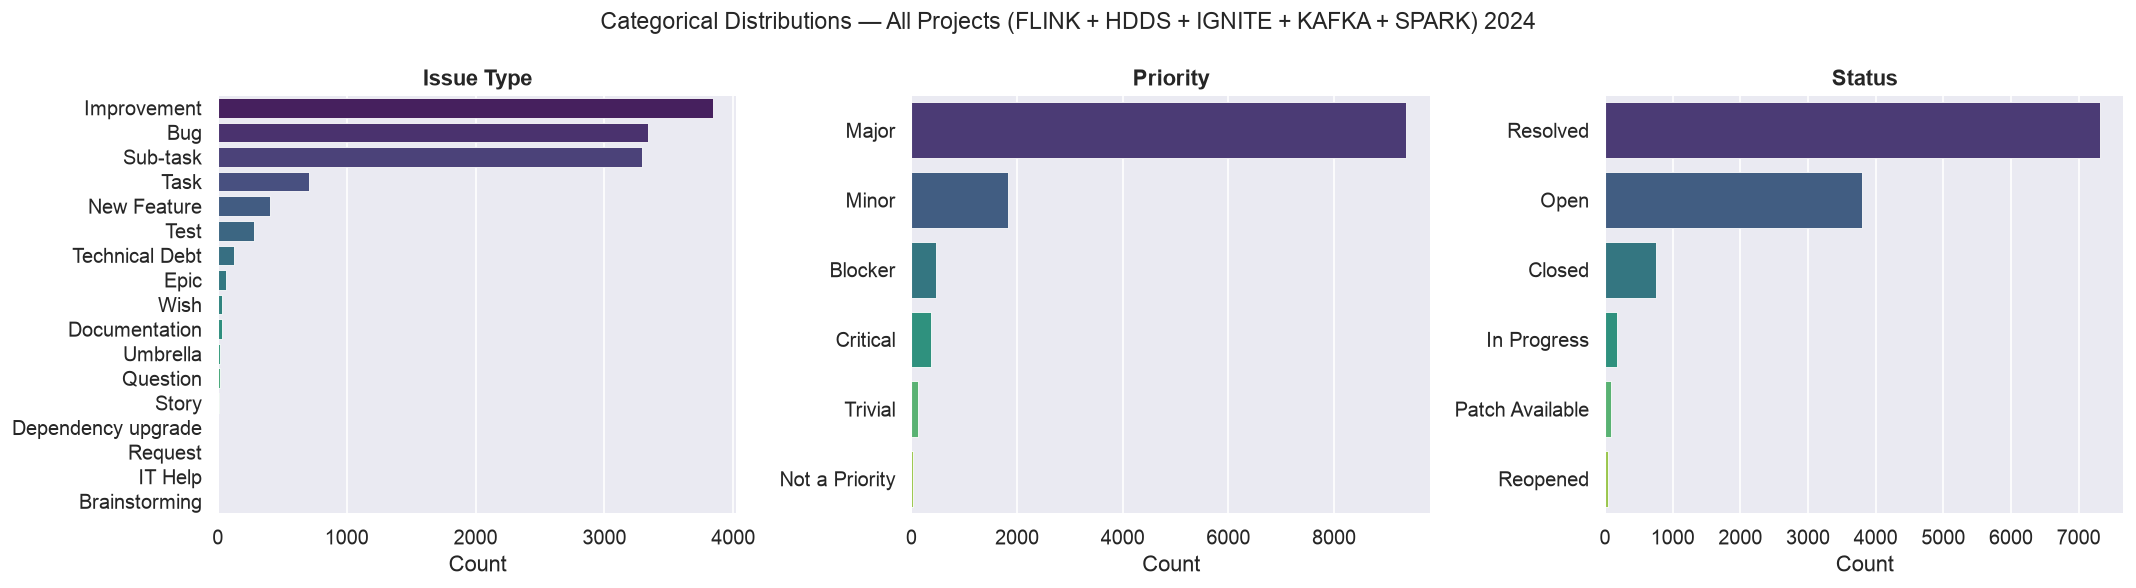

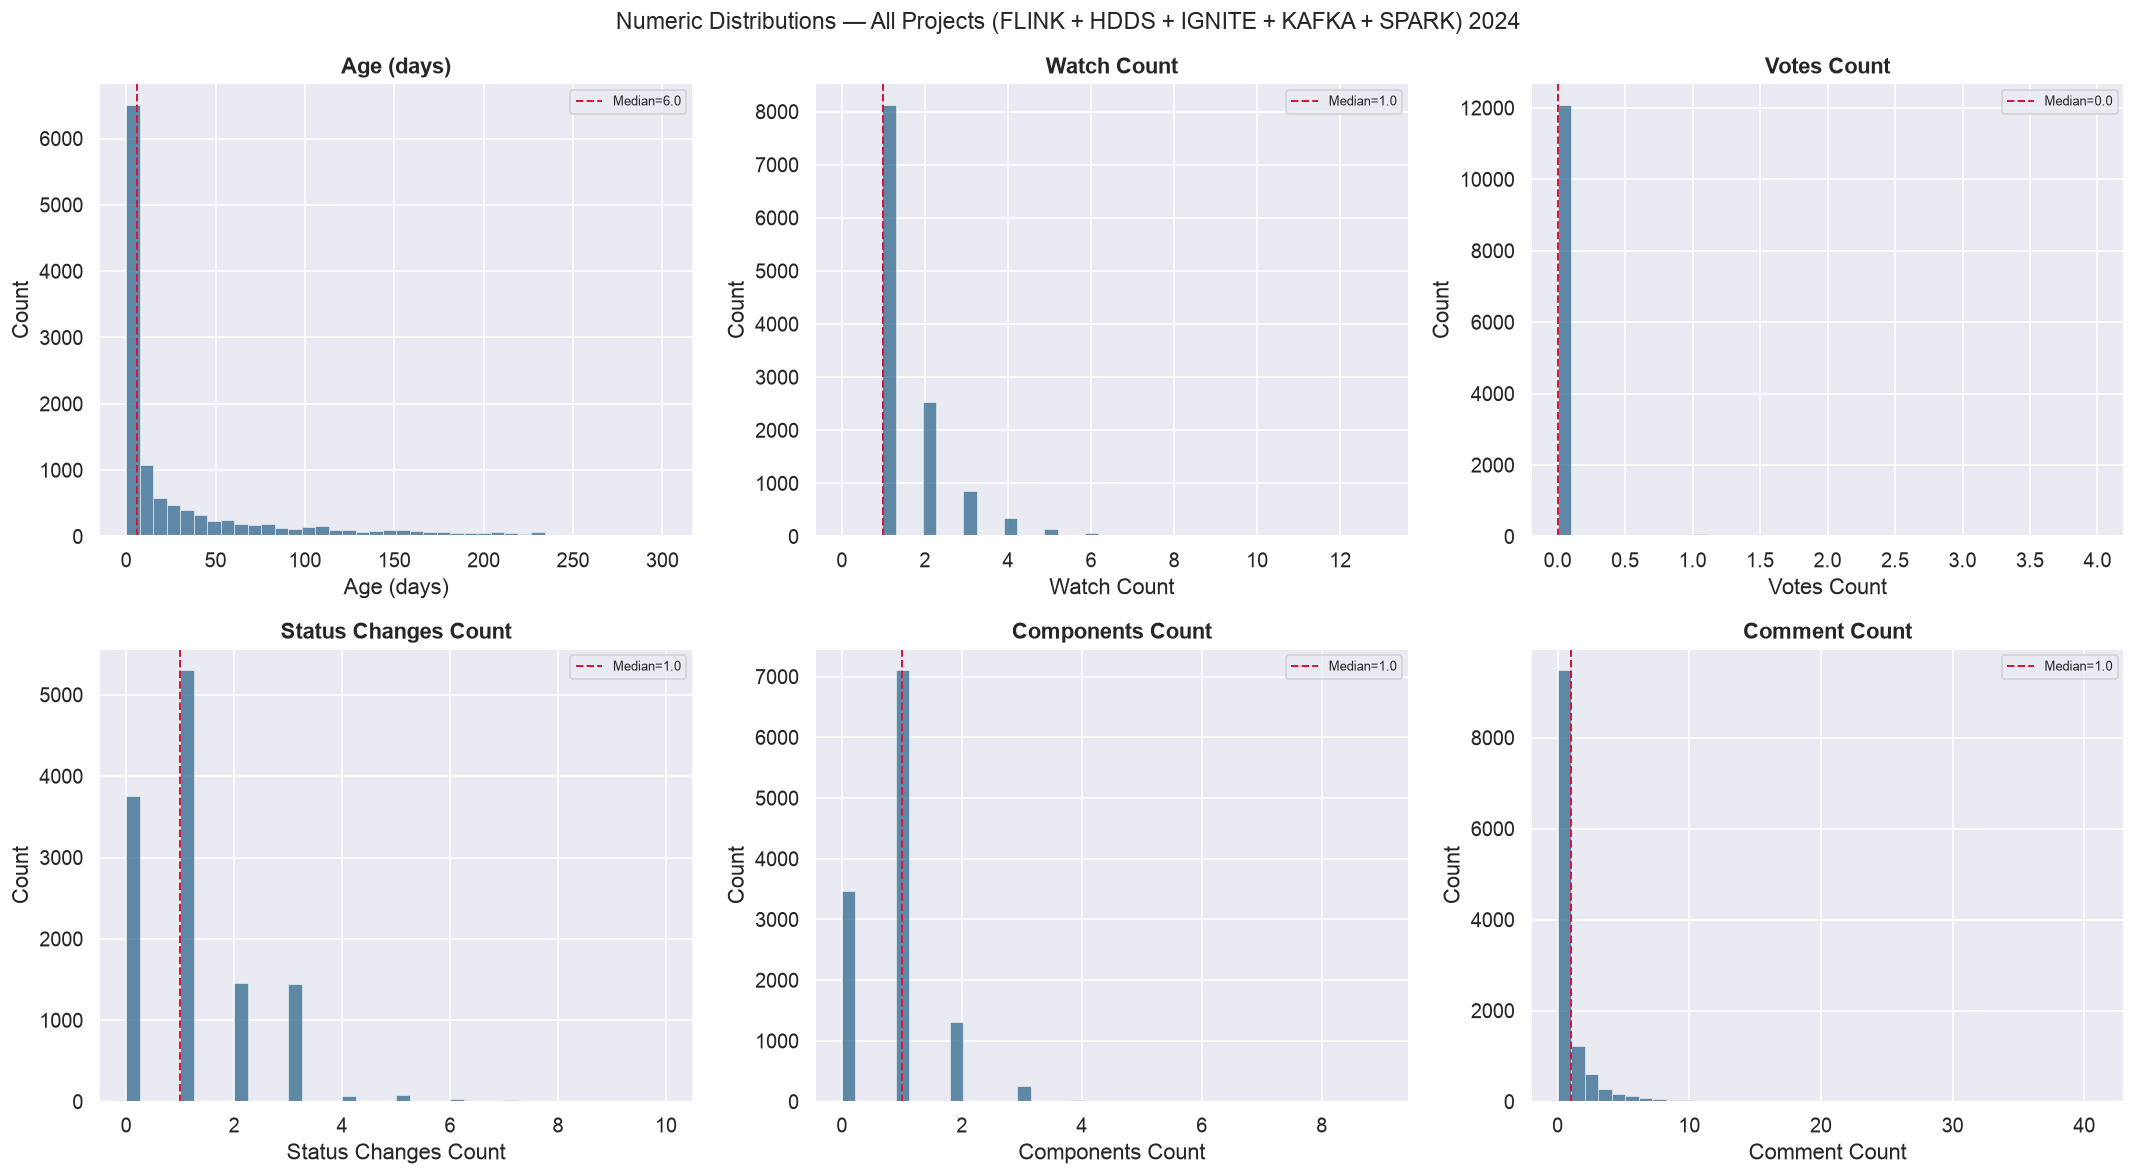


  Done — plots saved to: multi_plots/ALL


In [4]:
df_all = run_full_analysis(
    df       = df_raw,
    label    = 'All Projects (FLINK + HDDS + IGNITE + KAFKA + SPARK) 2024',
    plot_dir = PLOTS_ROOT / 'ALL',
)


---
# 2 · Apache Flink



  ANALYSIS: Apache Flink 2024  (2,682 issues)
  Working frame: 2,682 rows x 13 cols

  Status distribution:
status_name
Open           1223
Resolved        719
Closed          684
In Progress      51
Reopened          5


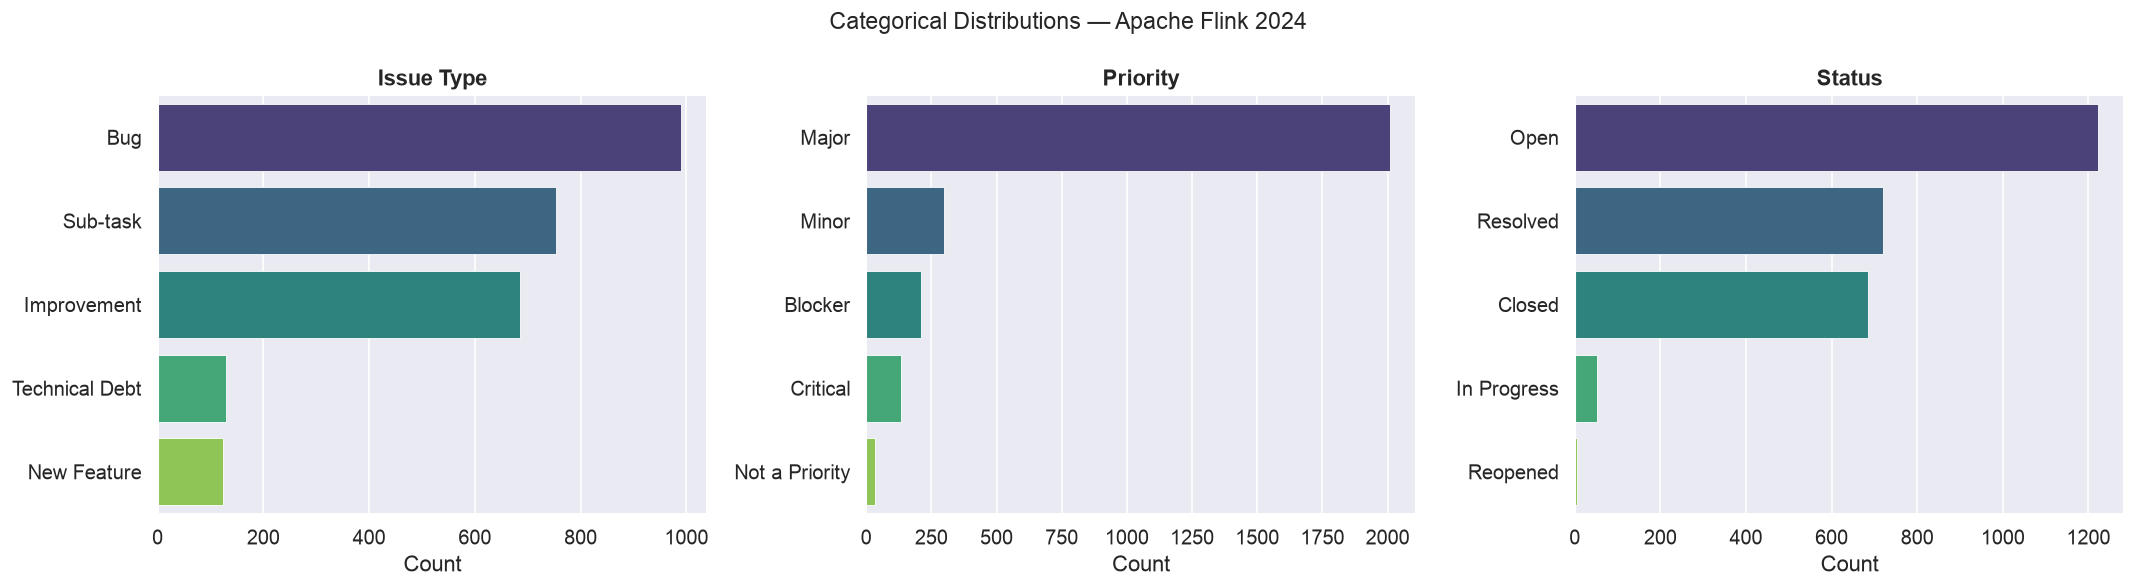

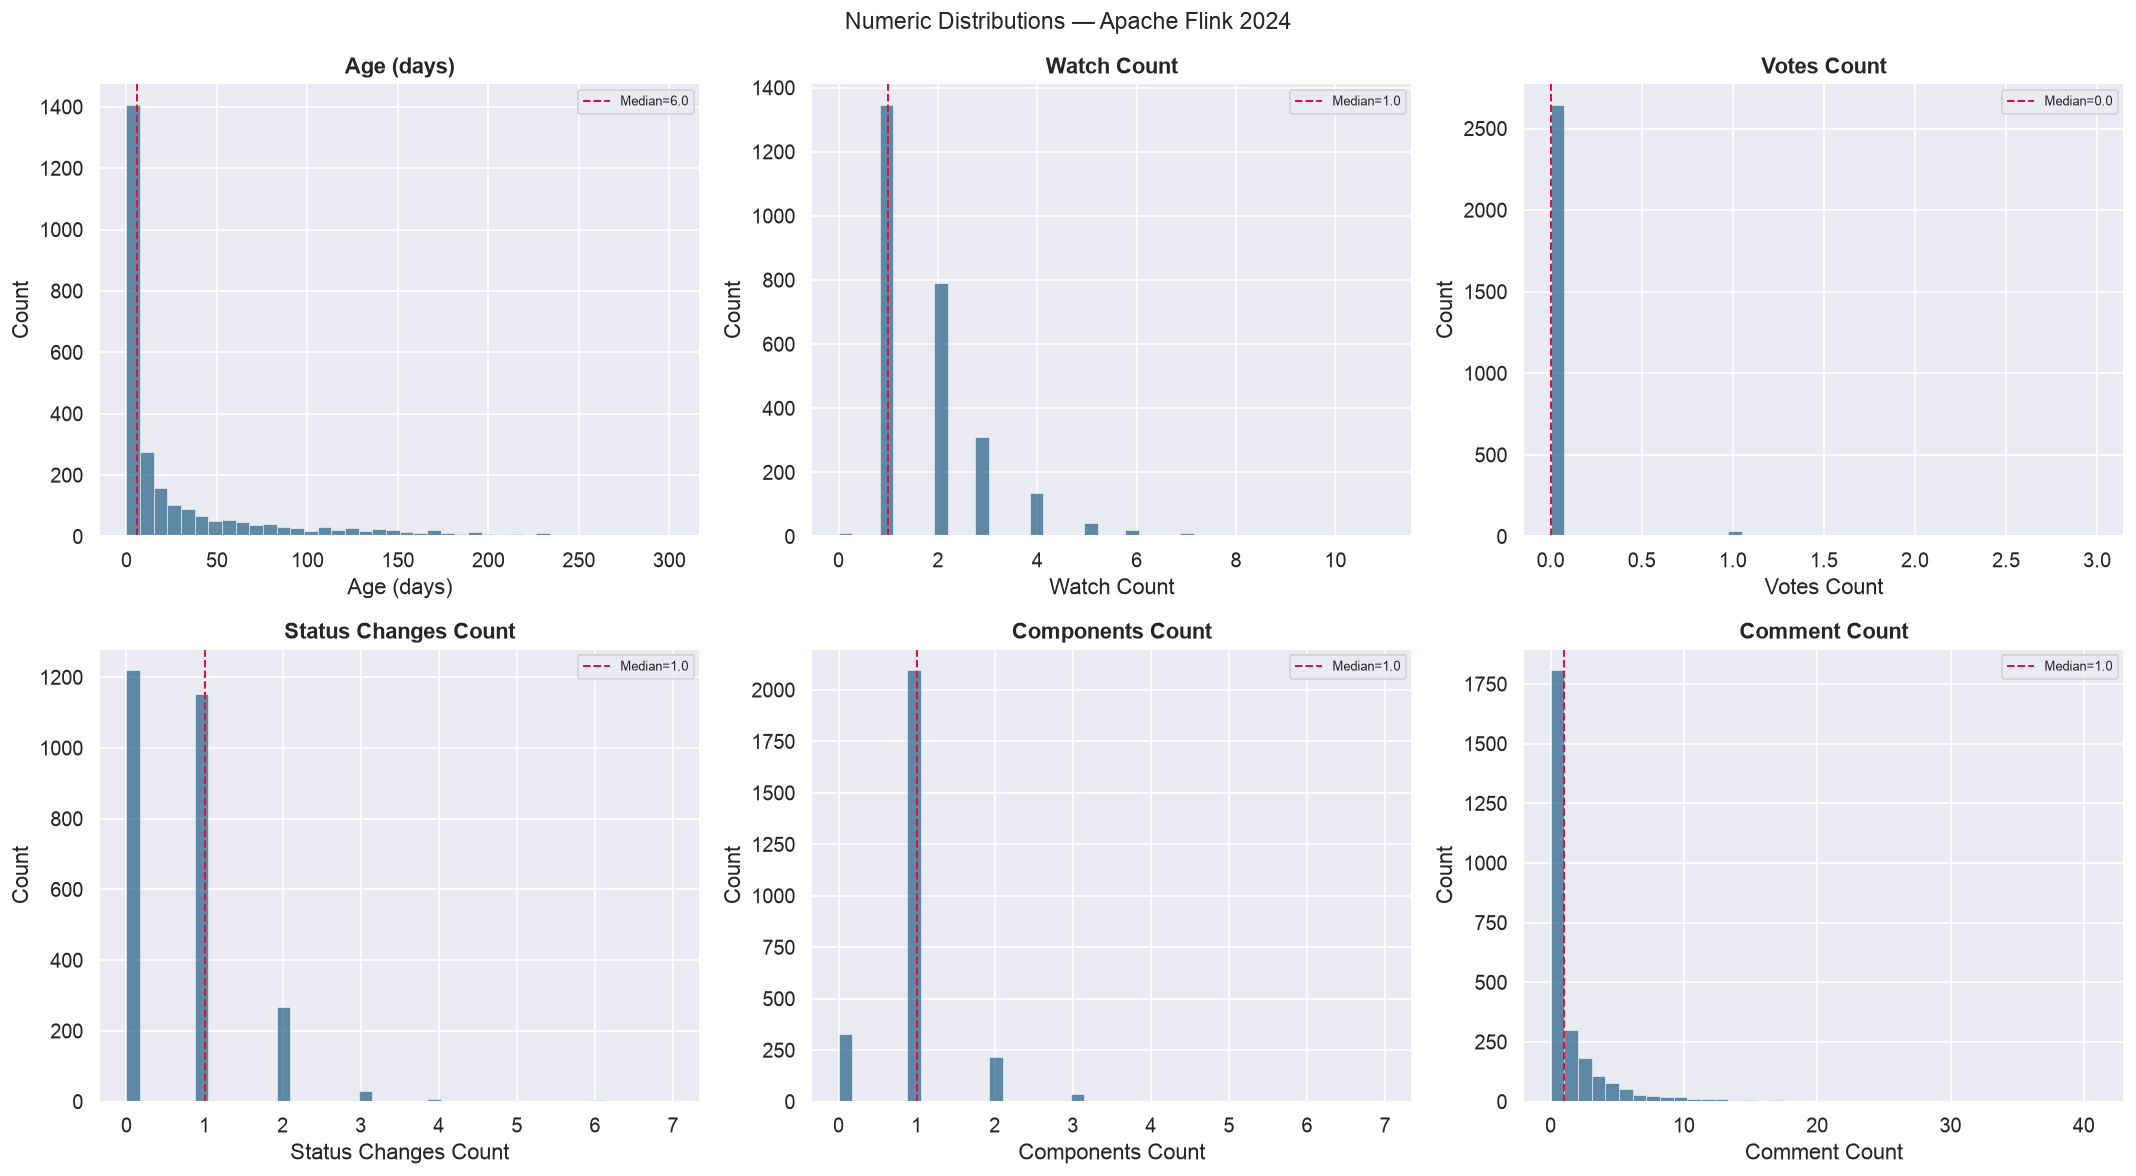


  Done — plots saved to: multi_plots/FLINK


In [5]:
df_flink = run_full_analysis(
    df       = df_raw[df_raw['project'] == 'FLINK'].copy(),
    label    = 'Apache Flink 2024',
    plot_dir = PLOTS_ROOT / 'FLINK',
)


---
# 3 · Apache Hadoop HDDS



  ANALYSIS: Apache Hadoop HDDS 2024  (1,591 issues)
  Working frame: 1,591 rows x 13 cols

  Status distribution:
status_name
Resolved           1127
Open                420
In Progress          29
Patch Available      10
Reopened              4
Closed                1


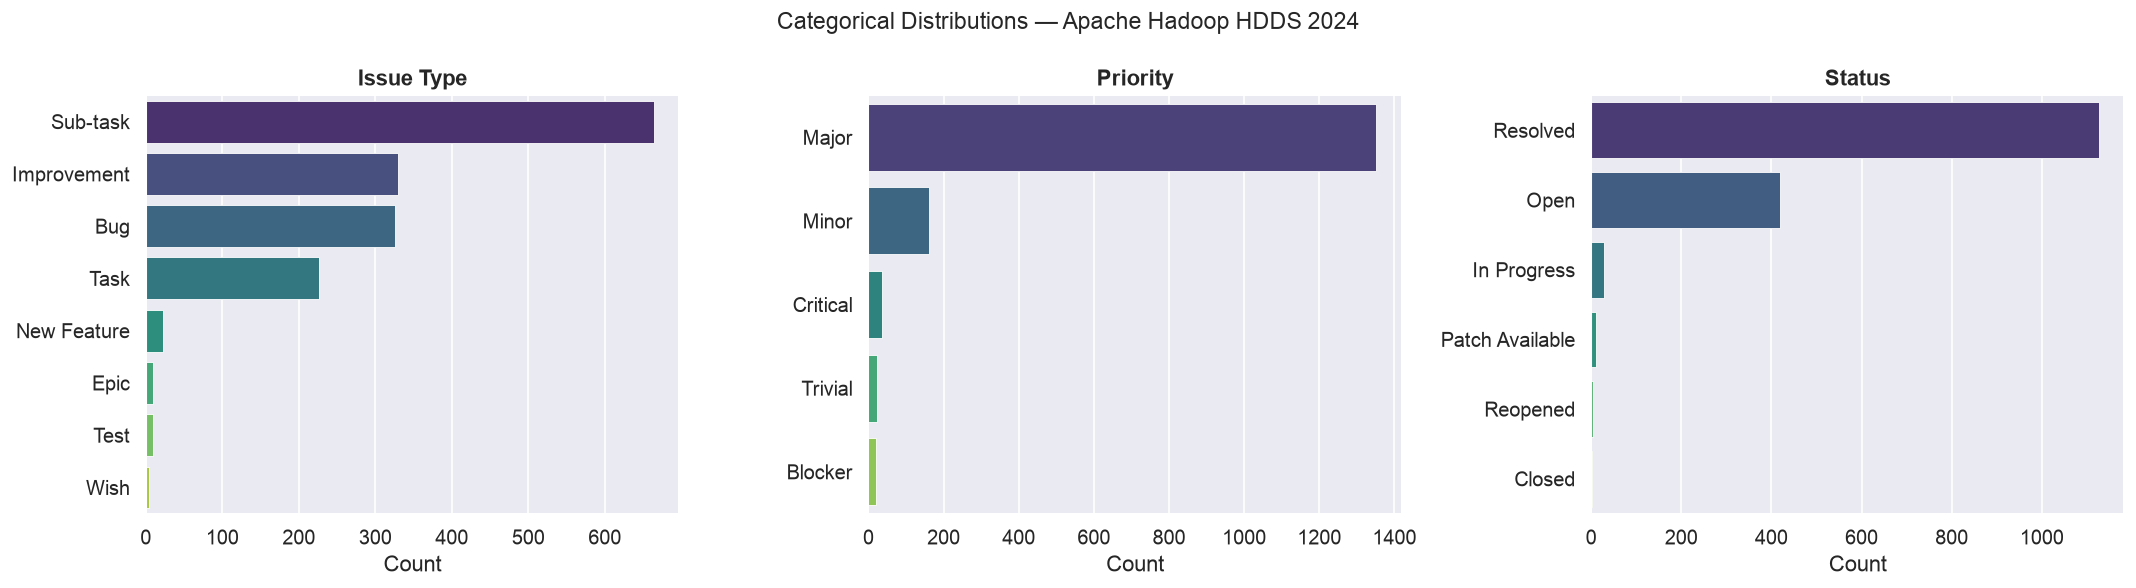

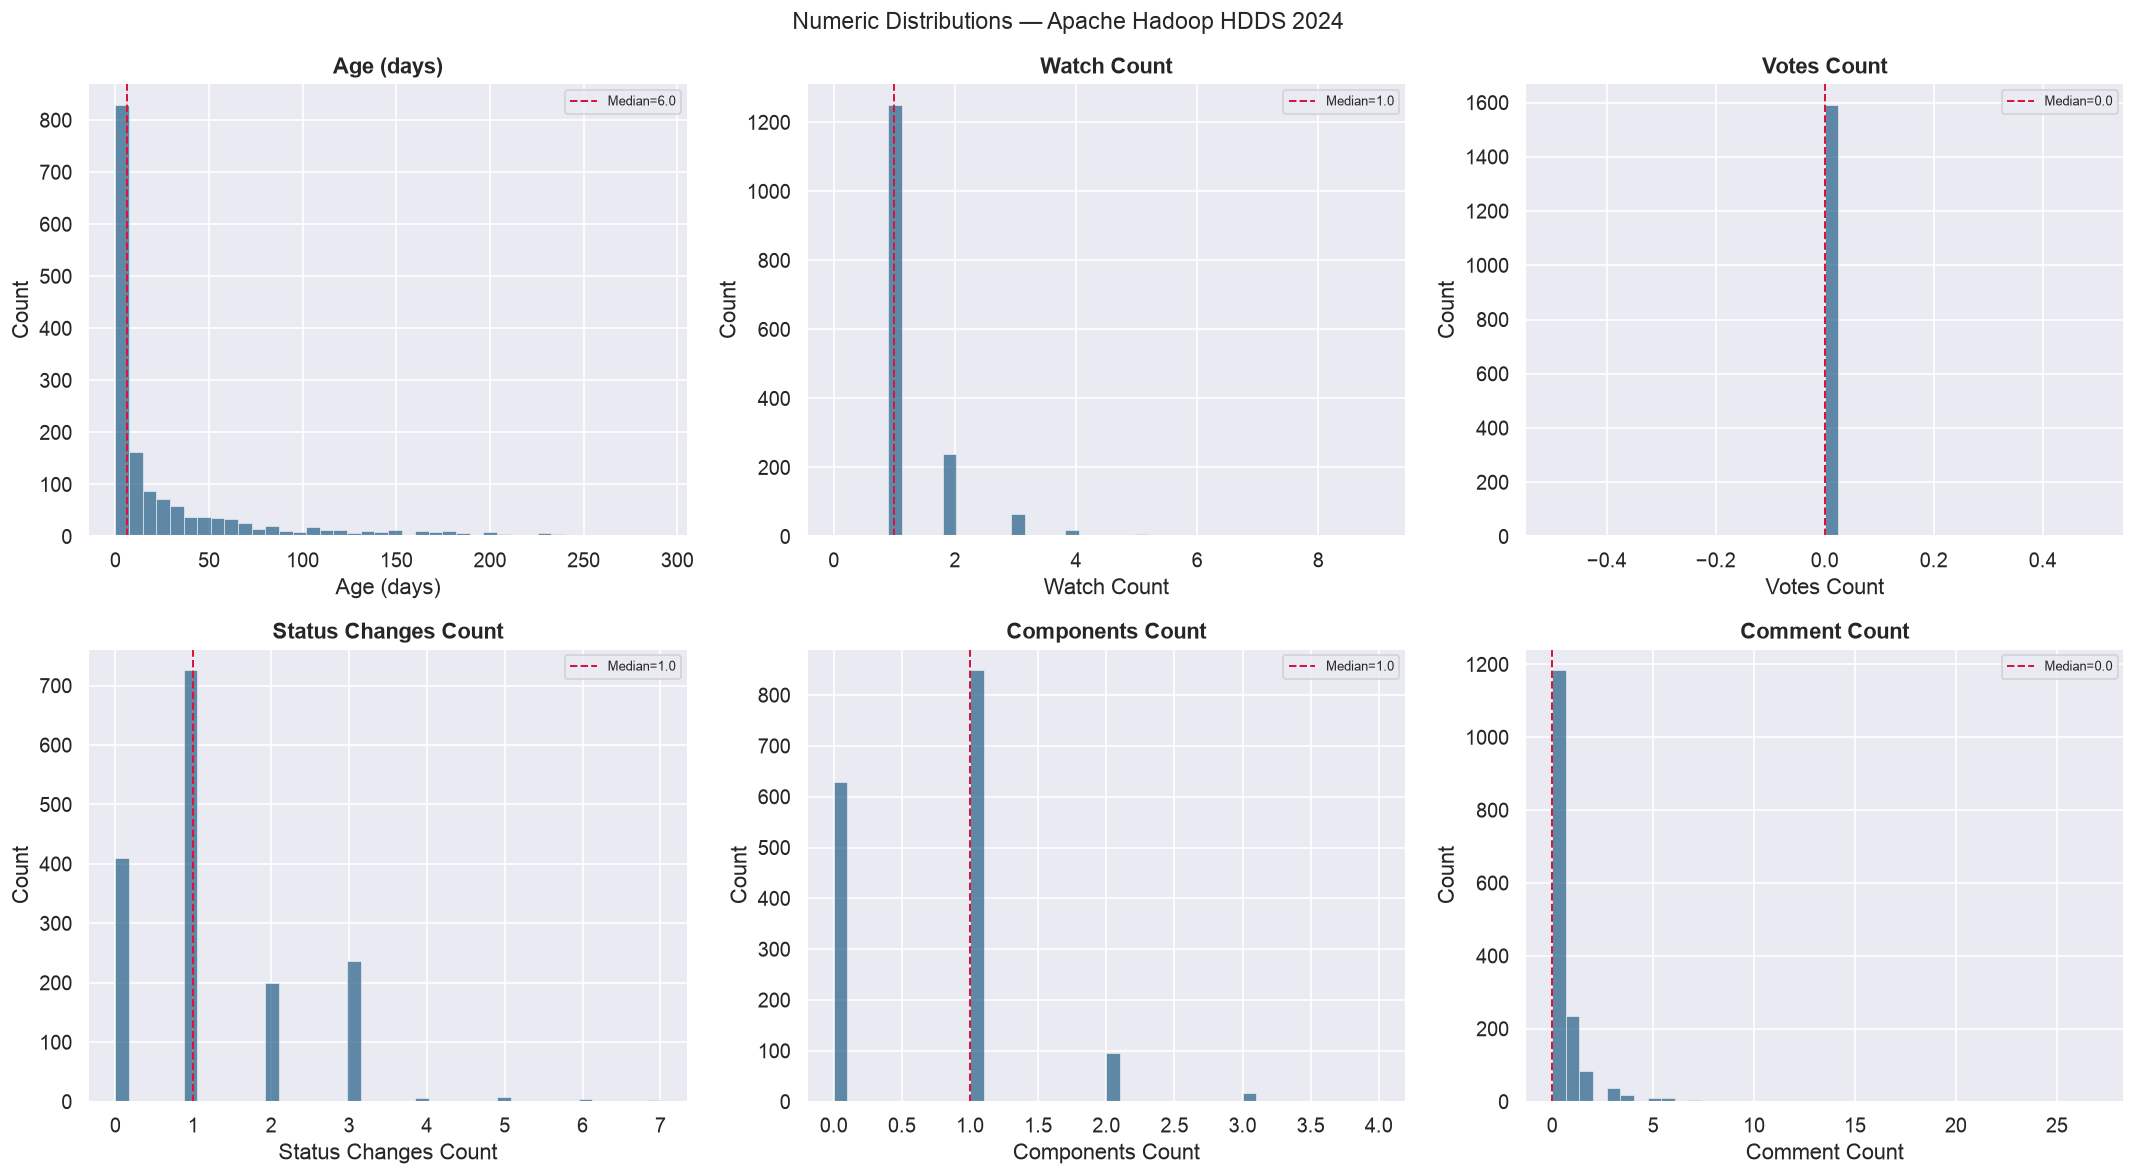


  Done — plots saved to: multi_plots/HDDS


In [6]:
df_hdds = run_full_analysis(
    df       = df_raw[df_raw['project'] == 'HDDS'].copy(),
    label    = 'Apache Hadoop HDDS 2024',
    plot_dir = PLOTS_ROOT / 'HDDS',
)


---
# 4 · Apache Ignite



  ANALYSIS: Apache Ignite 2024  (2,400 issues)
  Working frame: 2,400 rows x 13 cols

  Status distribution:
status_name
Resolved           1544
Open                768
Patch Available      35
In Progress          28
Closed               19
Reopened              6


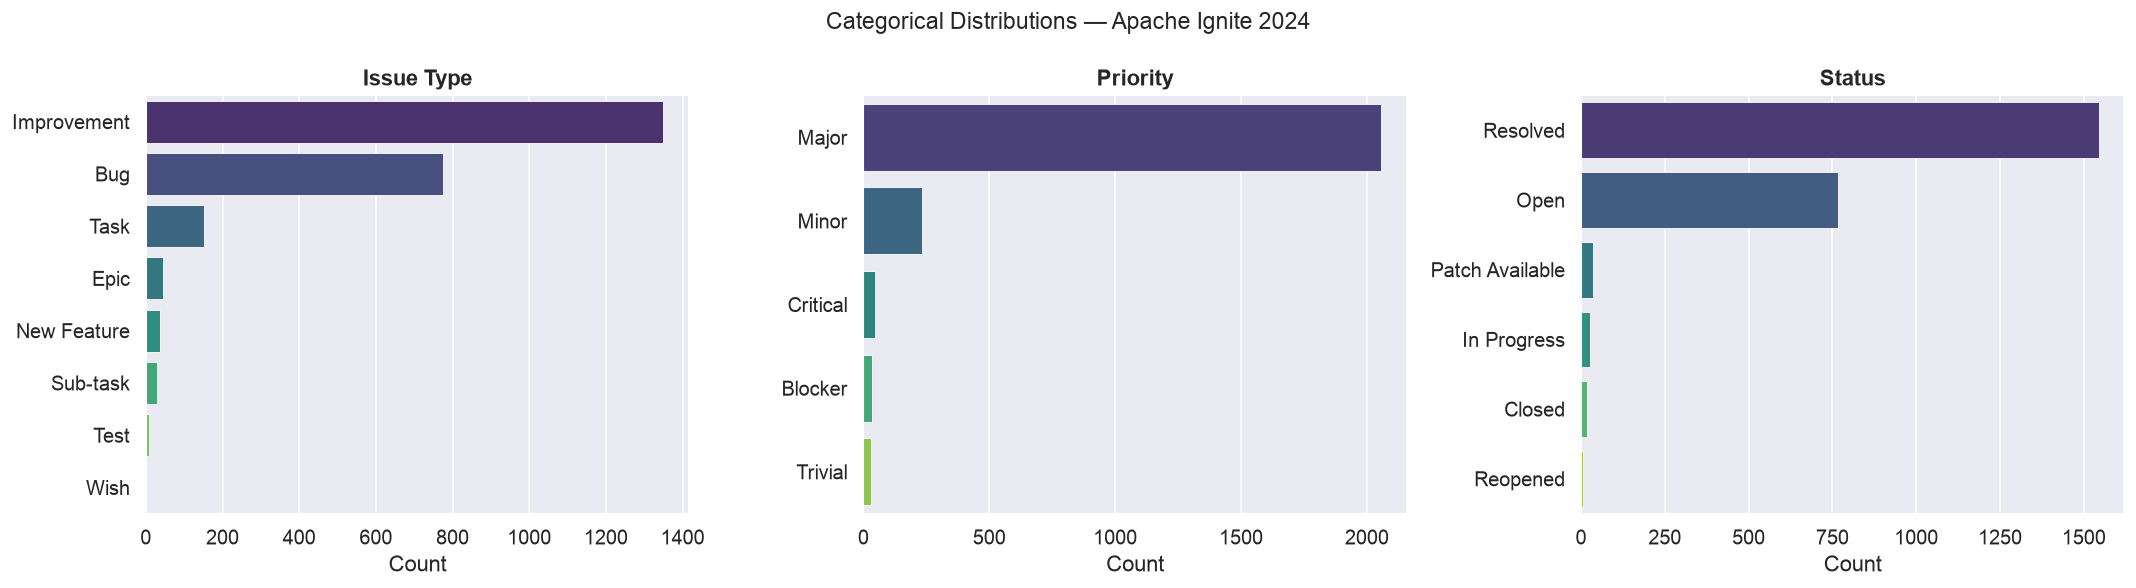

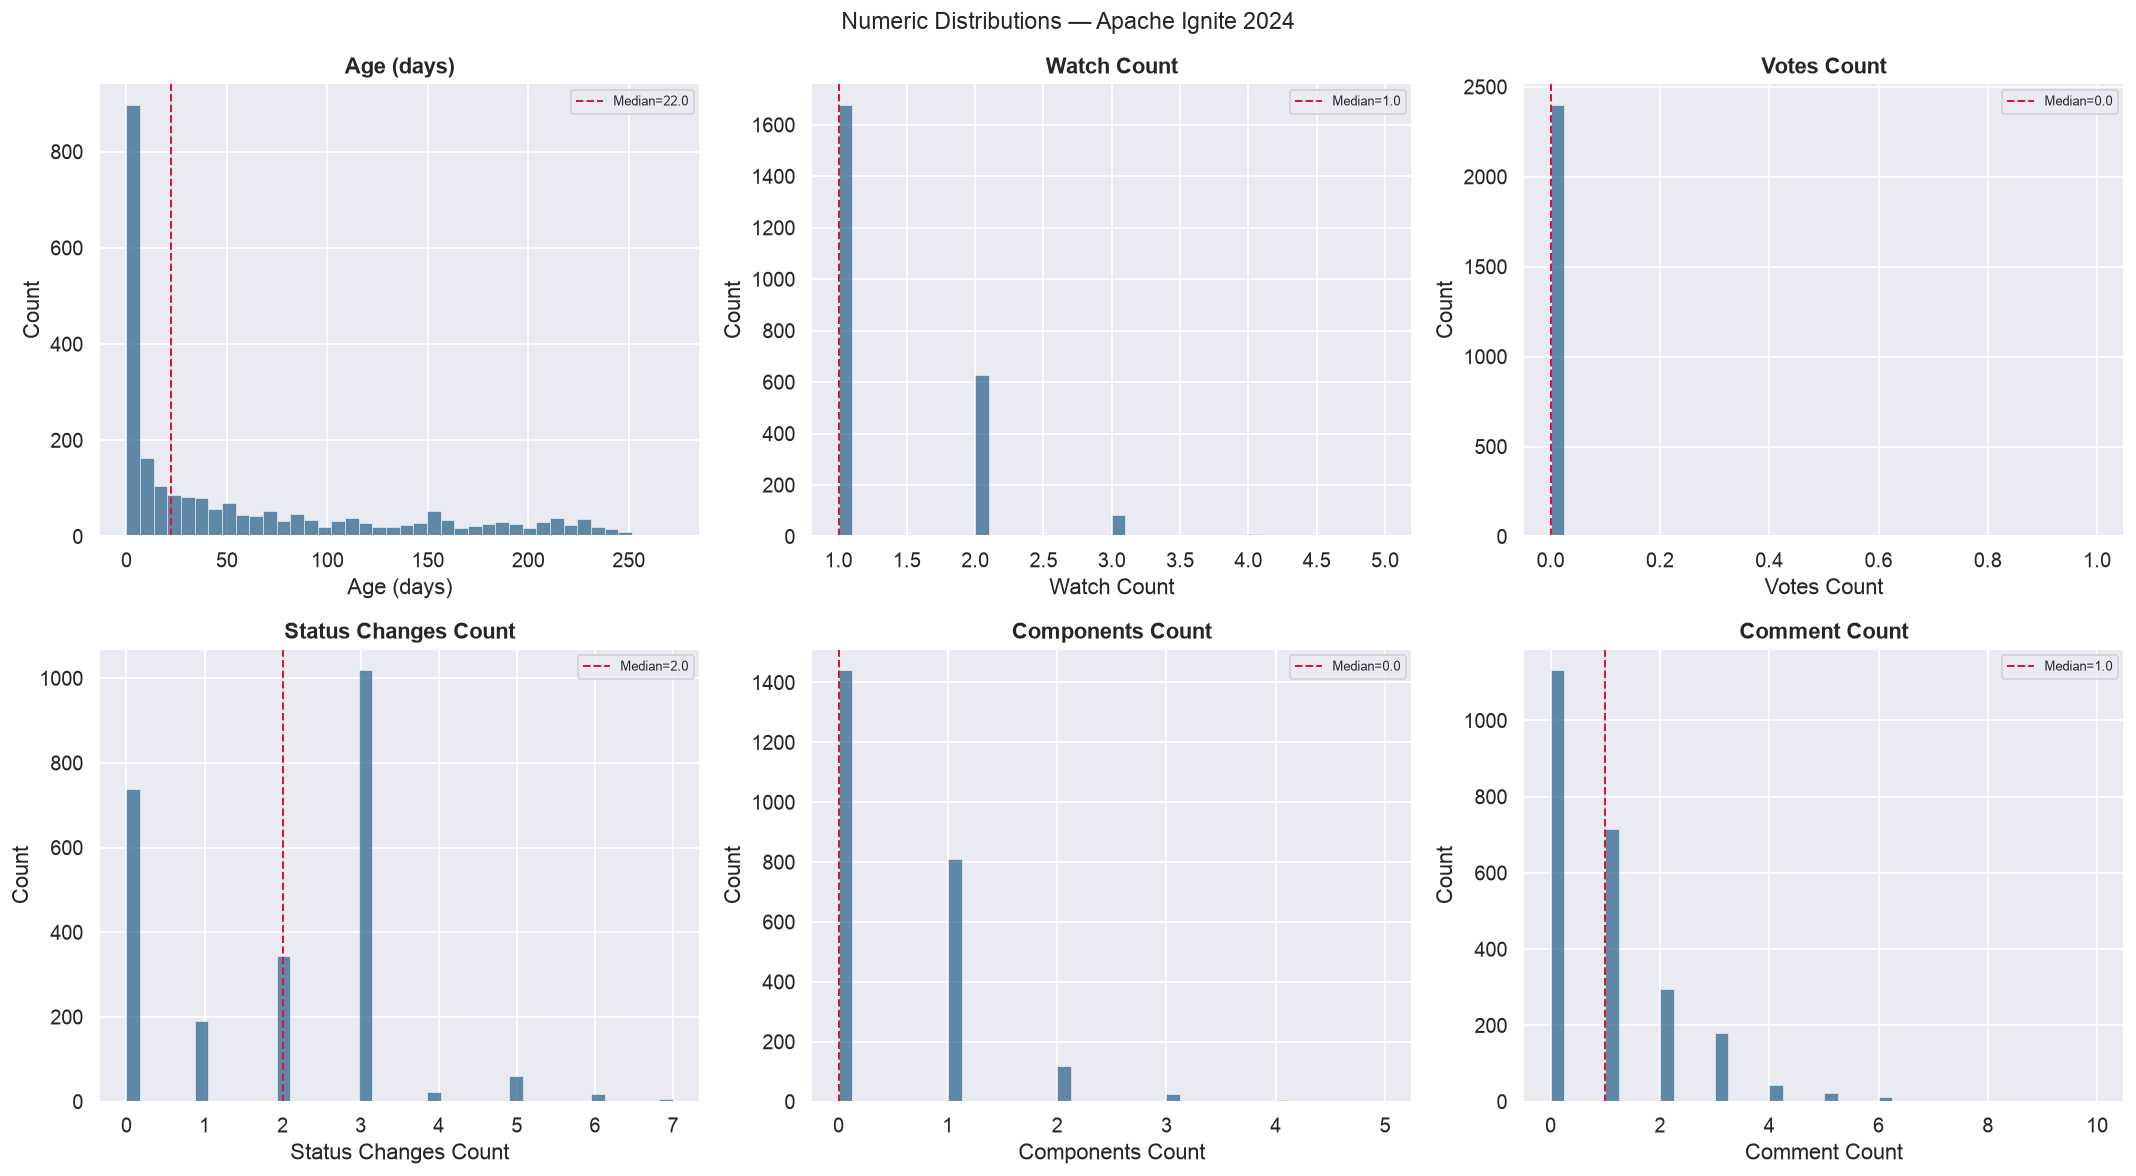


  Done — plots saved to: multi_plots/IGNITE


In [7]:
df_ignite = run_full_analysis(
    df       = df_raw[df_raw['project'] == 'IGNITE'].copy(),
    label    = 'Apache Ignite 2024',
    plot_dir = PLOTS_ROOT / 'IGNITE',
)


---
# 5 · Apache Kafka



  ANALYSIS: Apache Kafka 2024  (1,845 issues)
  Working frame: 1,845 rows x 13 cols

  Status distribution:
status_name
Resolved           1124
Open                584
In Progress          65
Patch Available      43
Closed               20
Reopened              9


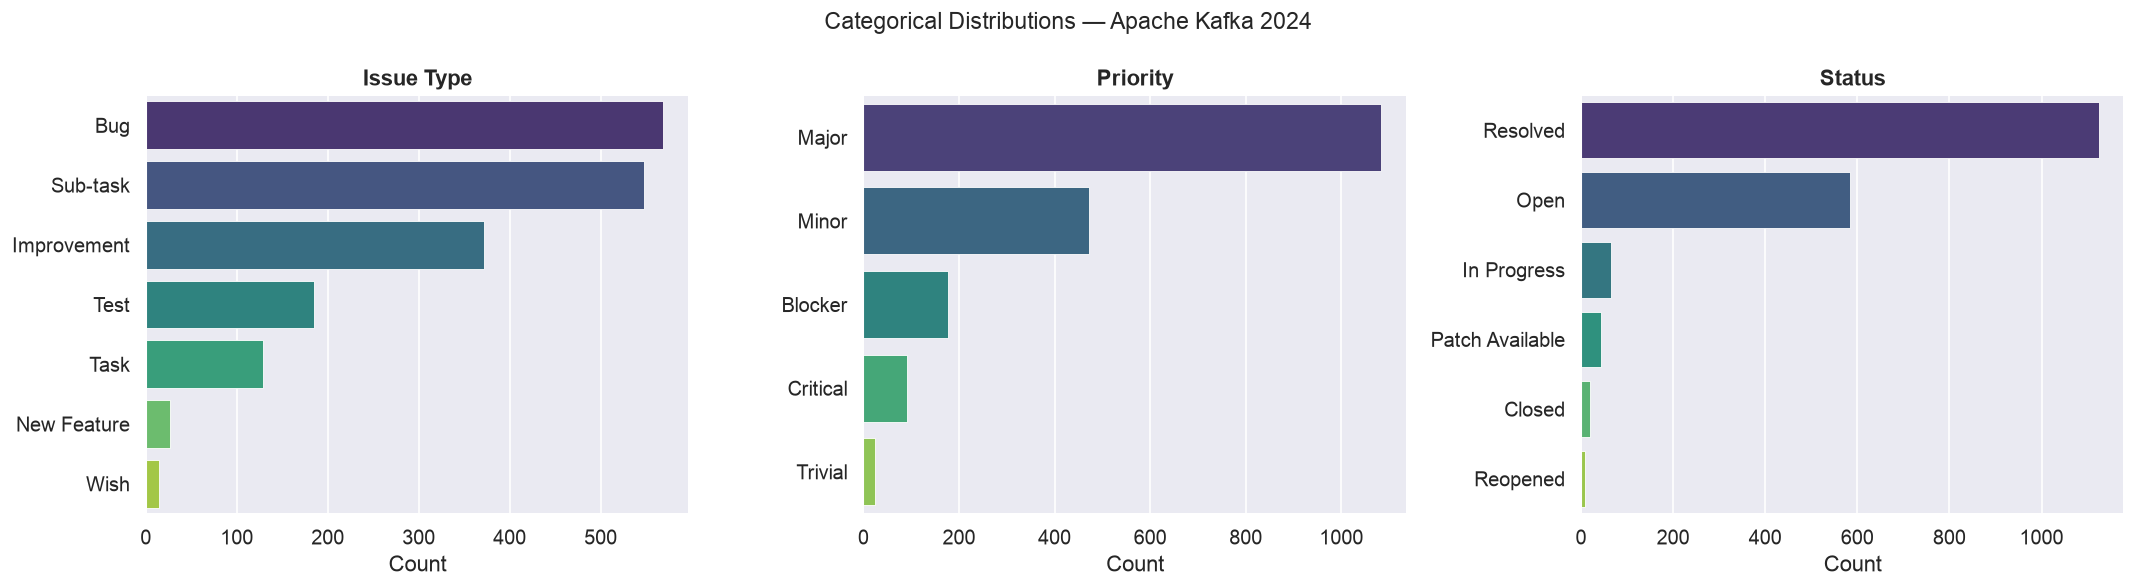

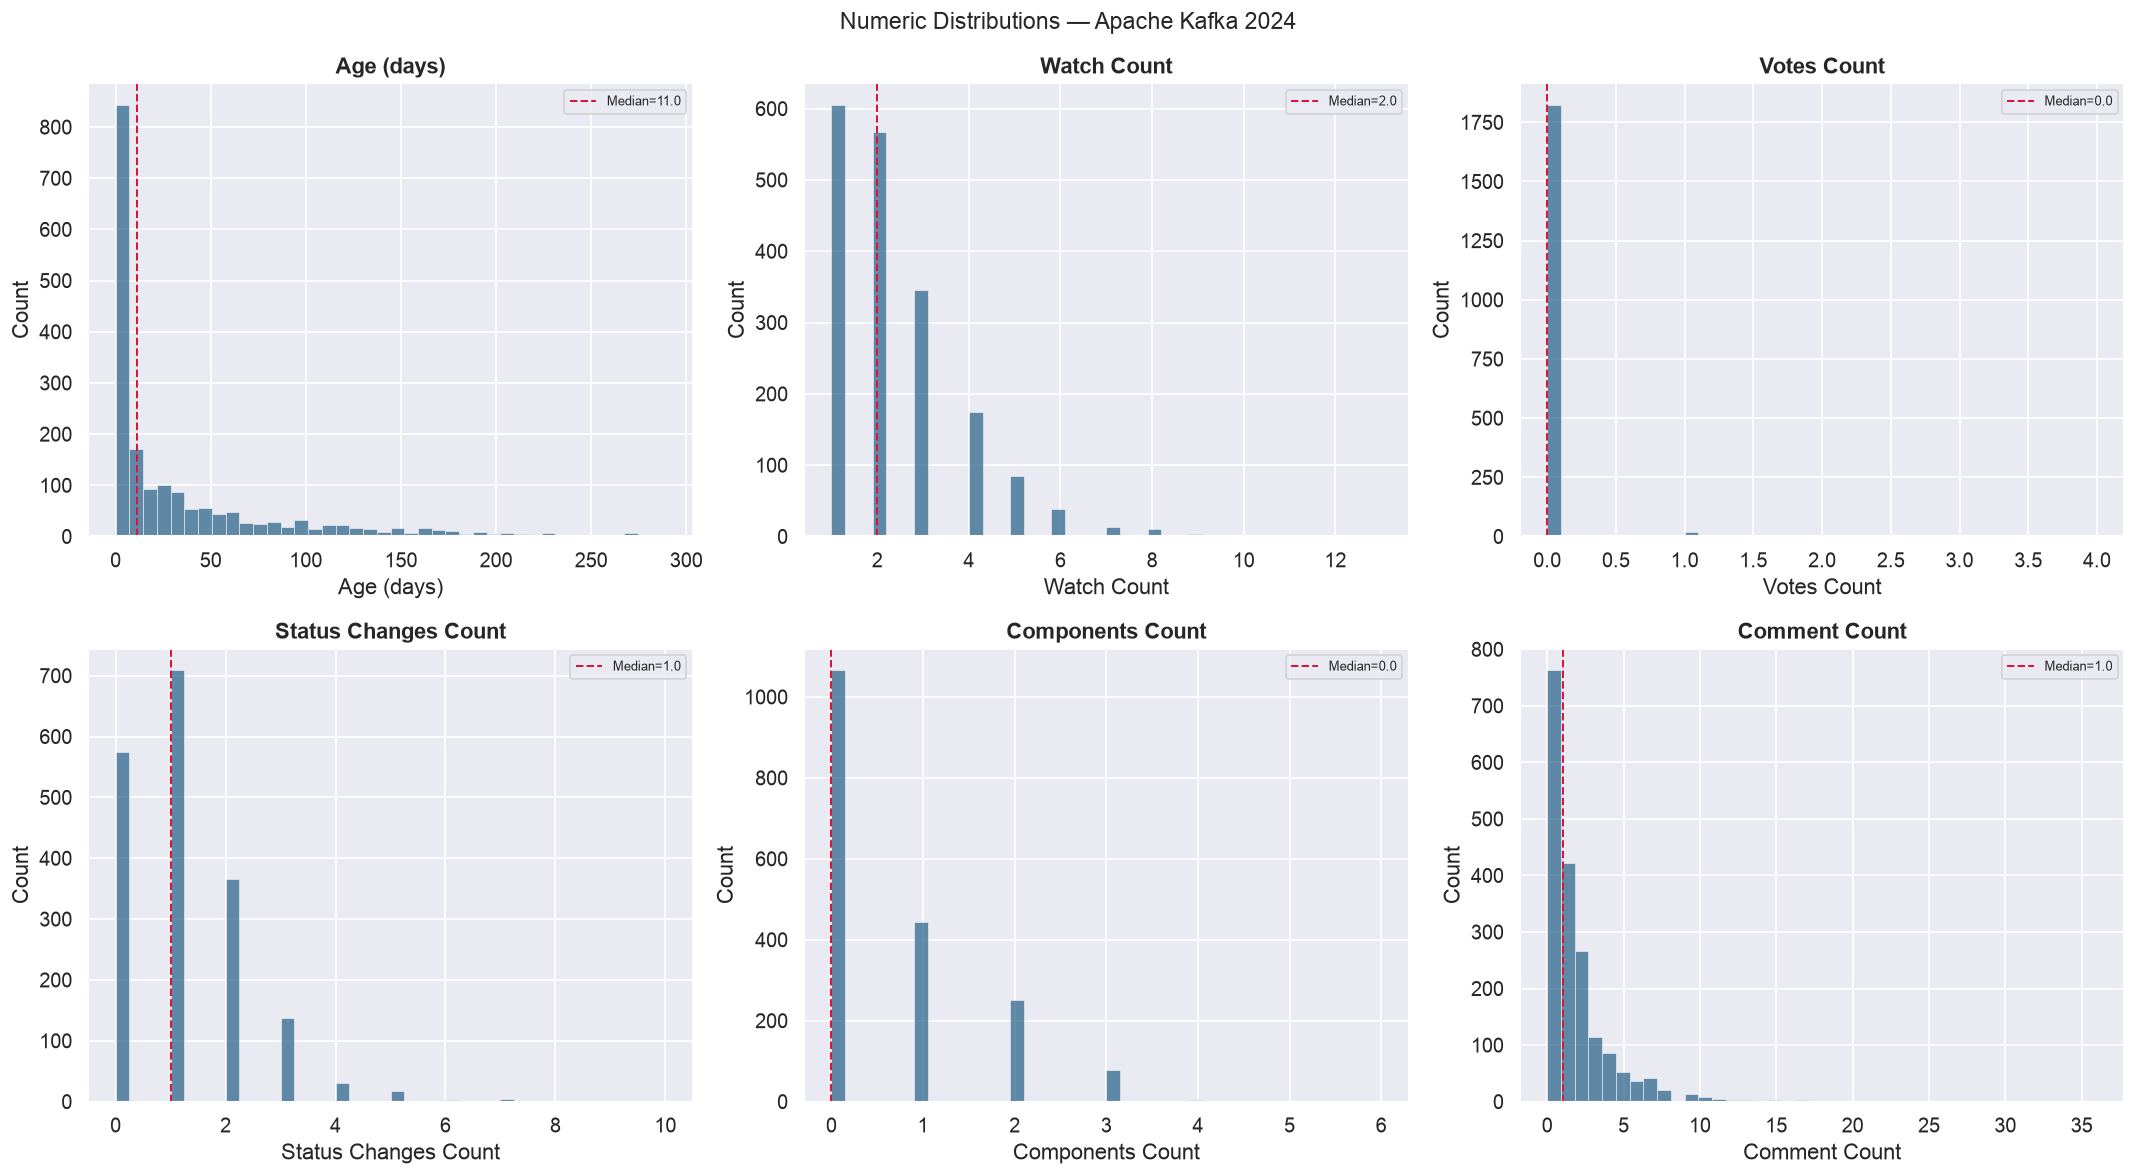


  Done — plots saved to: multi_plots/KAFKA


In [8]:
df_kafka = run_full_analysis(
    df       = df_raw[df_raw['project'] == 'KAFKA'].copy(),
    label    = 'Apache Kafka 2024',
    plot_dir = PLOTS_ROOT / 'KAFKA',
)


---
# 6 · Apache Spark



  ANALYSIS: Apache Spark 2024  (3,651 issues)
  Working frame: 3,651 rows x 13 cols

  Status distribution:
status_name
Resolved       2798
Open            808
Closed           24
Reopened         17
In Progress       4


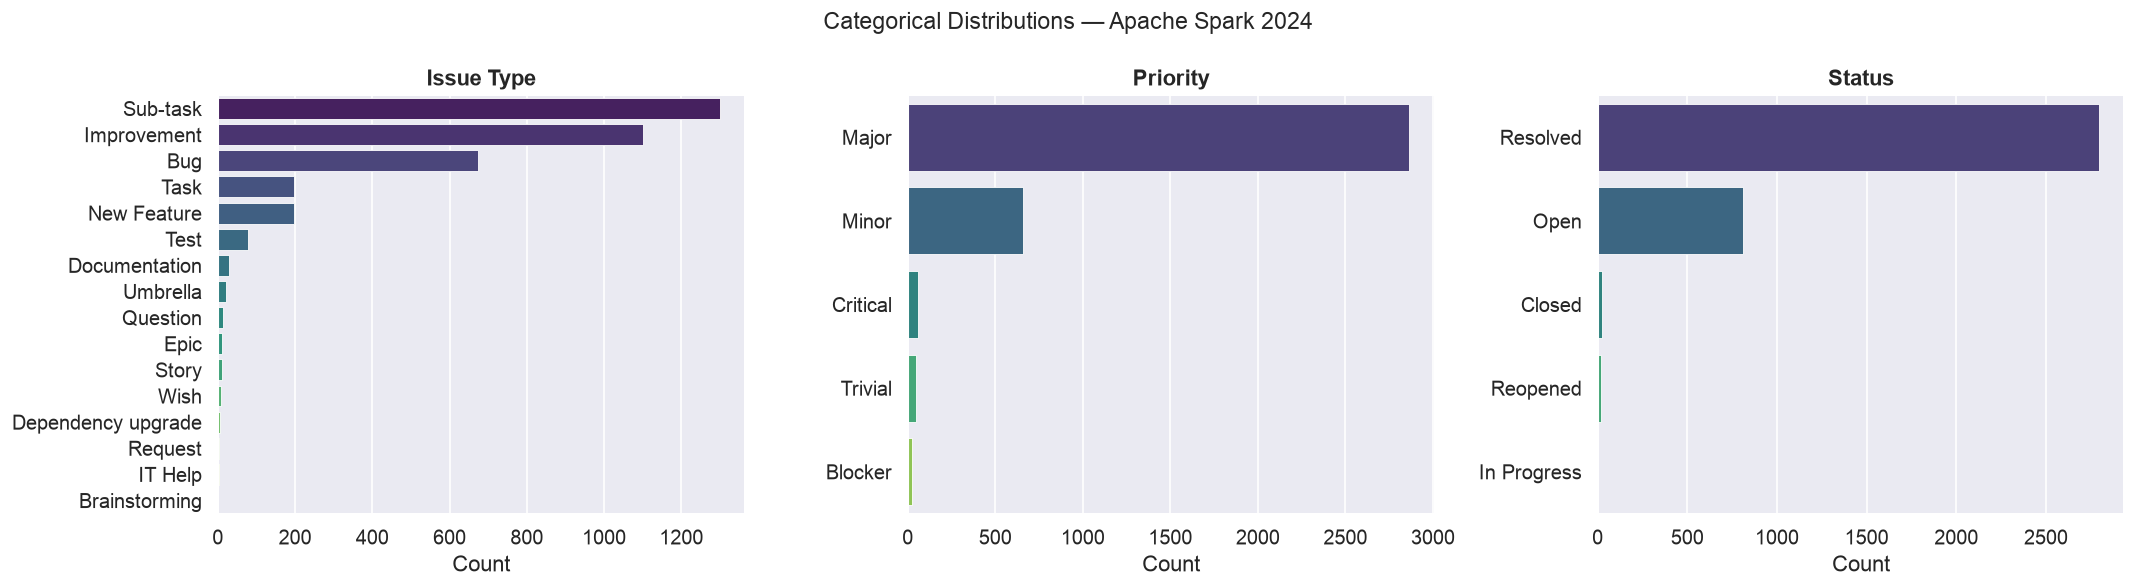

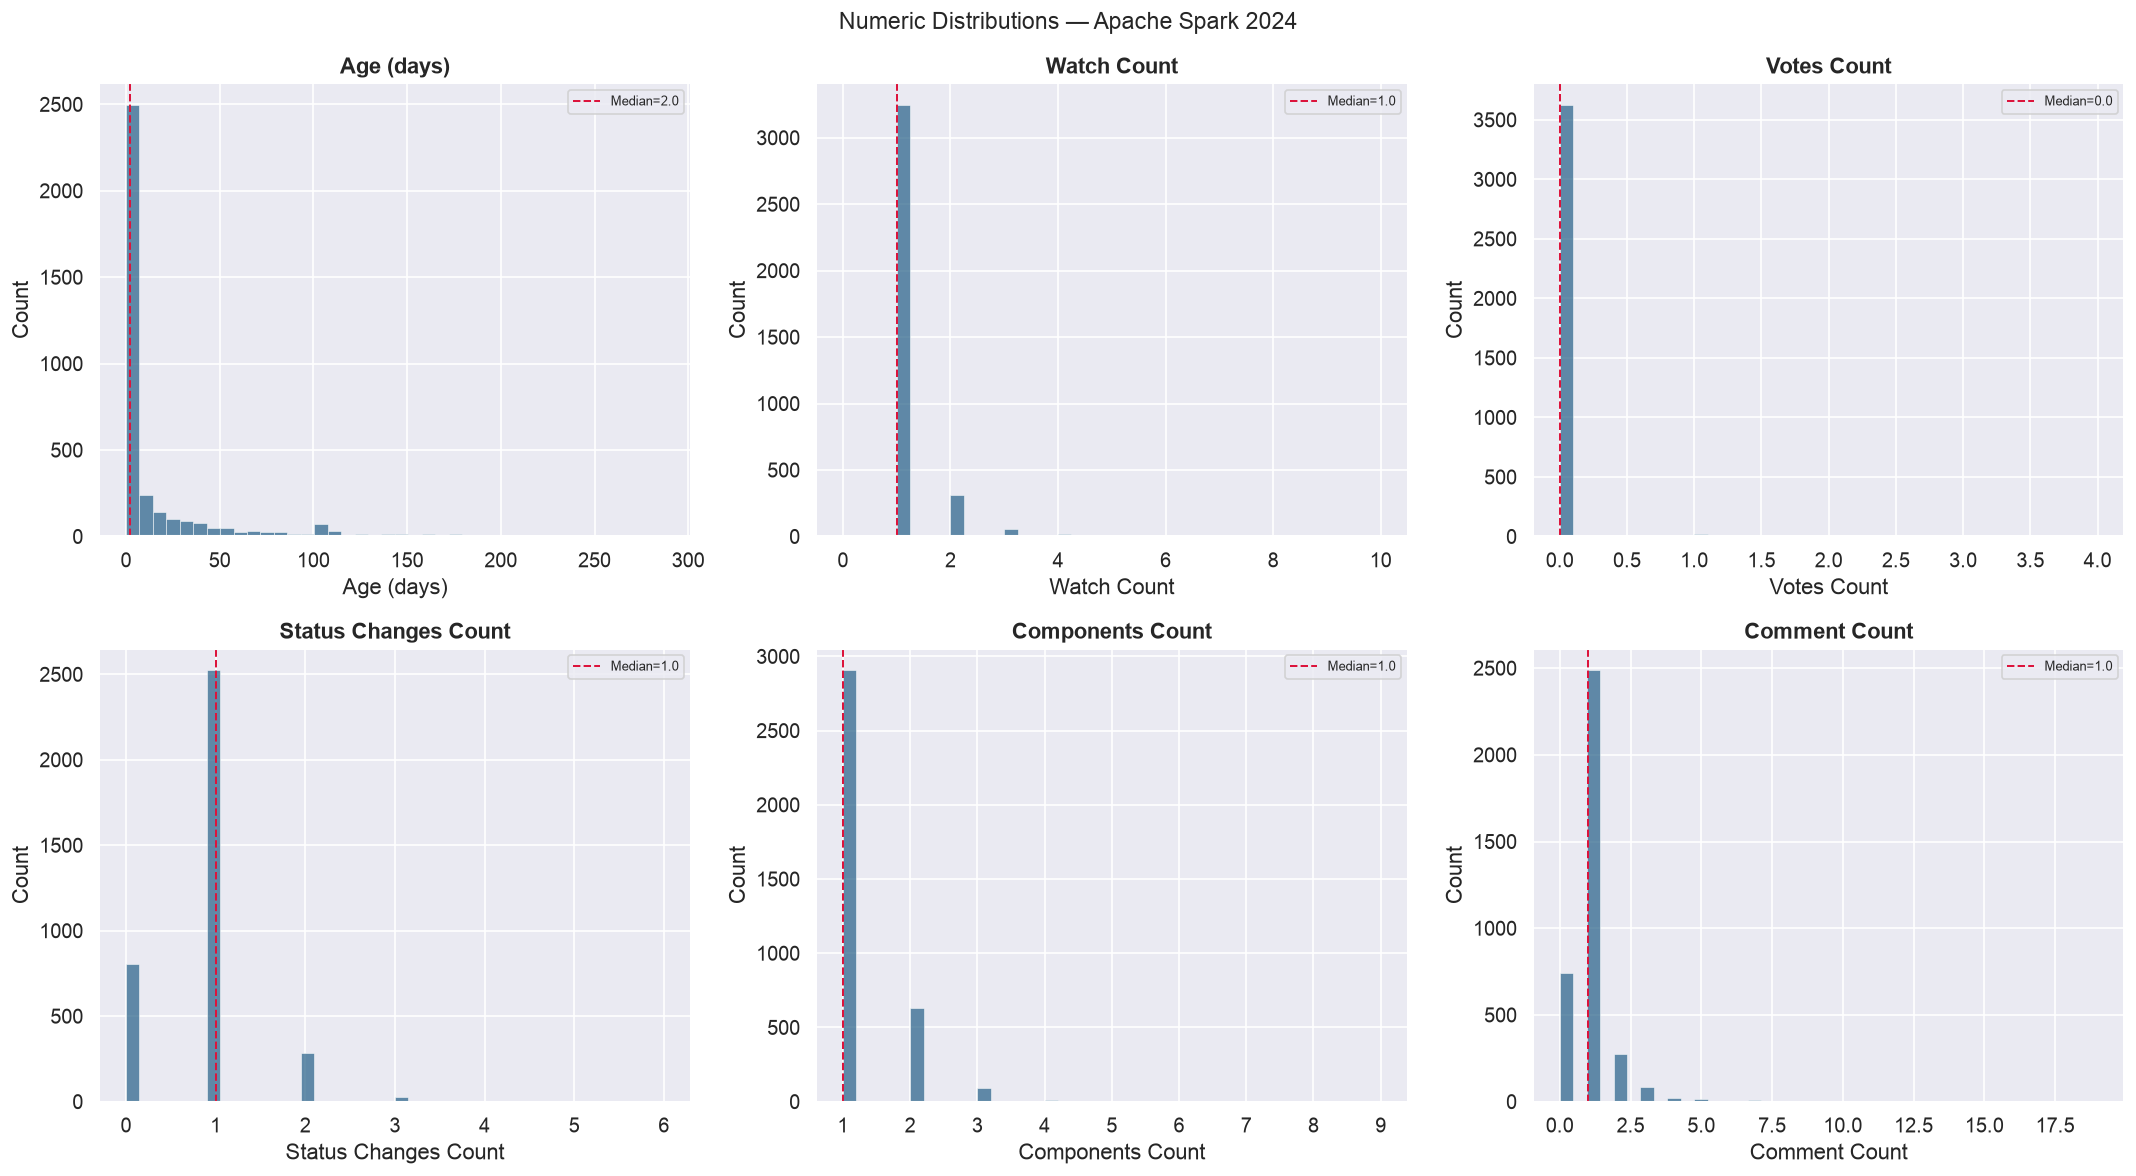


  Done — plots saved to: multi_plots/SPARK


In [9]:
df_spark = run_full_analysis(
    df       = df_raw[df_raw['project'] == 'SPARK'].copy(),
    label    = 'Apache Spark 2024',
    plot_dir = PLOTS_ROOT / 'SPARK',
)


---
# 7 · Cross-Project Summary
Comparison of key metrics across all five projects.


,Issues,Resolved (%),Median Age (days),Assigned (%),Bugs (%)
Project,,,,,
FLINK,2682,52.3,6.0,57.0,36.9
HDDS,1591,70.9,6.0,77.1,20.5
IGNITE,2400,65.1,22.0,69.2,32.3
KAFKA,1845,62.0,11.0,79.8,30.8
SPARK,3651,77.3,2.0,74.8,18.5


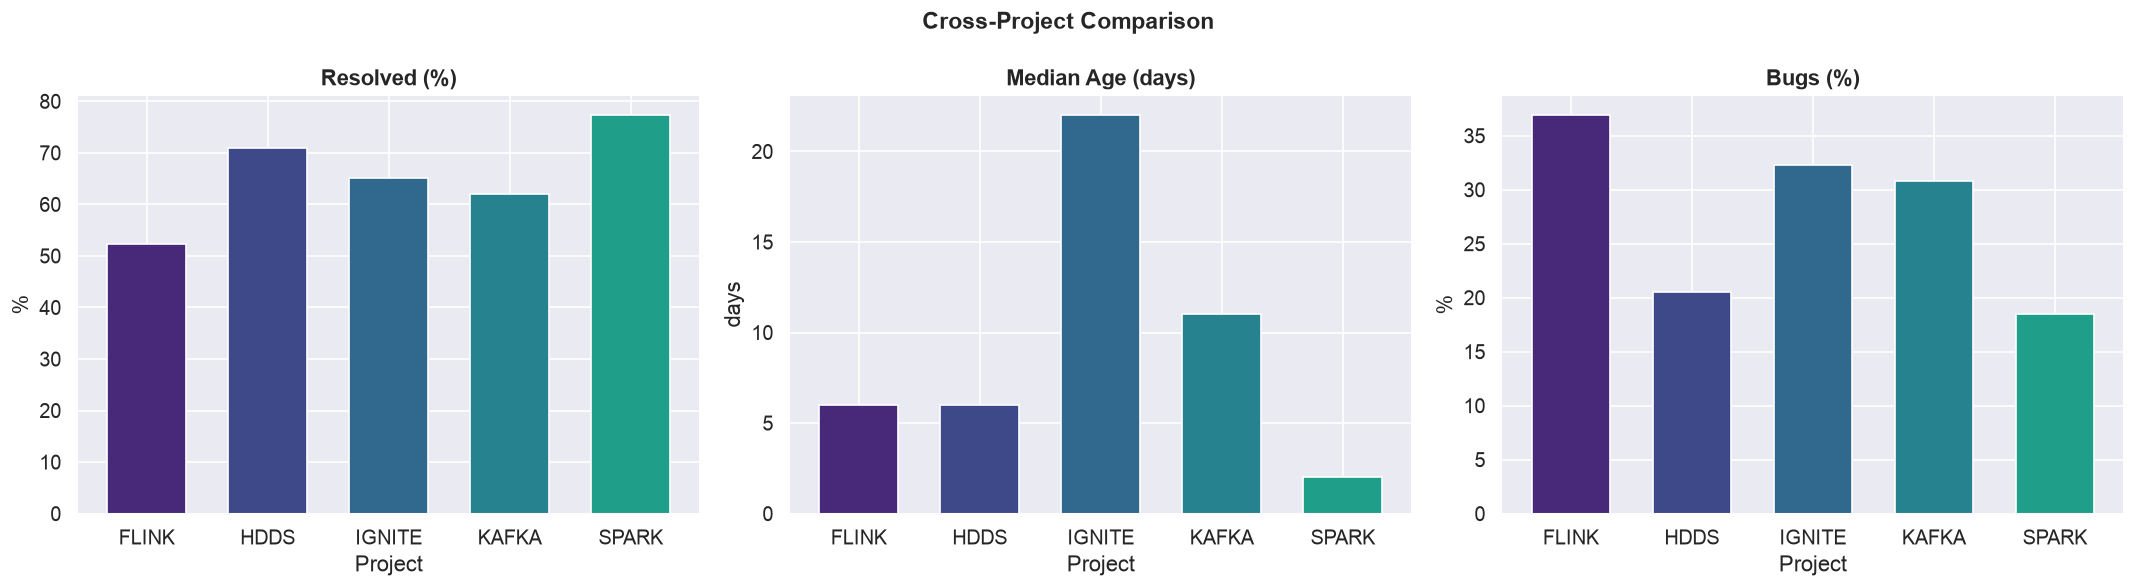

Saved -> multi_plots/cross_project_comparison.png


In [10]:
_projects = ['FLINK', 'HDDS', 'IGNITE', 'KAFKA', 'SPARK']

summary_rows = []
for proj in _projects:
    sub = preprocess(df_raw[df_raw['project'] == proj])
    resolved = sub['status_name'].isin(RESOLVED_STATUSES)
    summary_rows.append({
        'Project':            proj,
        'Issues':             len(sub),
        'Resolved (%)':       round(100 * resolved.mean(), 1),
        'Median Age (days)':  round(sub['age_days'].median(), 1),
        'Assigned (%)':       round(100 * sub['has_assignee'].mean(), 1),
        'Bugs (%)':           round(100 * (sub['issuetype_name'] == 'Bug').mean(), 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Project')
display(summary_df)

# Comparative bar charts
metrics = ['Resolved (%)', 'Median Age (days)', 'Bugs (%)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cross-Project Comparison', fontsize=14, fontweight='bold')
for ax, metric in zip(axes, metrics):
    summary_df[metric].plot.bar(ax=ax, color=PALETTE[:5], edgecolor='white', width=0.65)
    ax.set_title(metric); ax.set_ylabel(metric.split('(')[-1].rstrip(')'))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
cmp_path = PLOTS_ROOT / 'cross_project_comparison.png'
plt.savefig(cmp_path, bbox_inches='tight')
plt.show()
print(f'Saved -> {cmp_path}')
